In [2]:
from run_regression import *
from make_sample_df import *
from run_inference import *
%matplotlib inline

plt.rc('font', family='Malgun Gothic')

In [3]:
df = make_sample_df(n_features=10)
df = df.rename(columns={"F010":"DEFAULT"})

=====target : 10 DEFAULT=====
train: 201101~201812 자료 추출 중
validation set : 201501~201912 자료 추출 중
test set : 201701~202112 자료 추출 중
======1. TFT 모델 학습중======


c:\Users\rbs\anaconda3\envs\tft_env\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[TFT Epoch 001] train_loss=0.015104 | val_loss=0.023840 | test_loss=0.775191 | lr=1.00e-03
  -> saved best to ./output/260405220946/DEFAULT_tft_test_260405.pt
[TFT Epoch 002] train_loss=0.010675 | val_loss=0.048719 | test_loss=0.963838 | lr=1.00e-03
[TFT Epoch 003] train_loss=0.011003 | val_loss=0.019197 | test_loss=0.724111 | lr=1.00e-03
  -> saved best to ./output/260405220946/DEFAULT_tft_test_260405.pt
======2. LSTM 모델 학습중======
[LSTM Epoch 001] train_loss=0.018323 | val_loss=0.005695 | test_loss=0.275132 | lr=1.00e-03
  -> saved best LSTM to ./output/260405220946/DEFAULT_lstm_test_260405.pt
[LSTM Epoch 002] train_loss=0.008278 | val_loss=0.009537 | test_loss=0.250716 | lr=1.00e-03
[LSTM Epoch 003] train_loss=0.008266 | val_loss=0.046022 | test_loss=0.541369 | lr=1.00e-03
  -> early stopping
{'d_model': 64, 'hidden_dim': 4, 'lstm_hidden': 4, 'n_heads': 4, 'dropout': 0.2, 'past_vars': 10, 'known_vars': 1, 'static_vars': 1, 'output_mode': 'regression'}
====================output build

c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_regression.py:332: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax5, palette='Reds')
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_regression.py:337: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y=grp_cd, ax=ax6, palette='Greens_r')


==========시각화(7) 변동 방향성 혼동행렬(TFT)==========
==========시각화(8) 변동 방향성 혼동행렬(LSTM)==========


c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_regression.py:354: RuntimeWarning: invalid value encountered in divide
  sns.heatmap(cm_tft / cm_tft.sum(axis=1)[:, None], annot=True, fmt=".1%", cmap='Blues', ax=ax7,
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_regression.py:362: RuntimeWarning: invalid value encountered in divide
  sns.heatmap(cm_lstm / cm_lstm.sum(axis=1)[:, None], annot=True, fmt=".1%", cmap='Blues', ax=ax8,


==========시각화(9) Temporal Attention Score==========


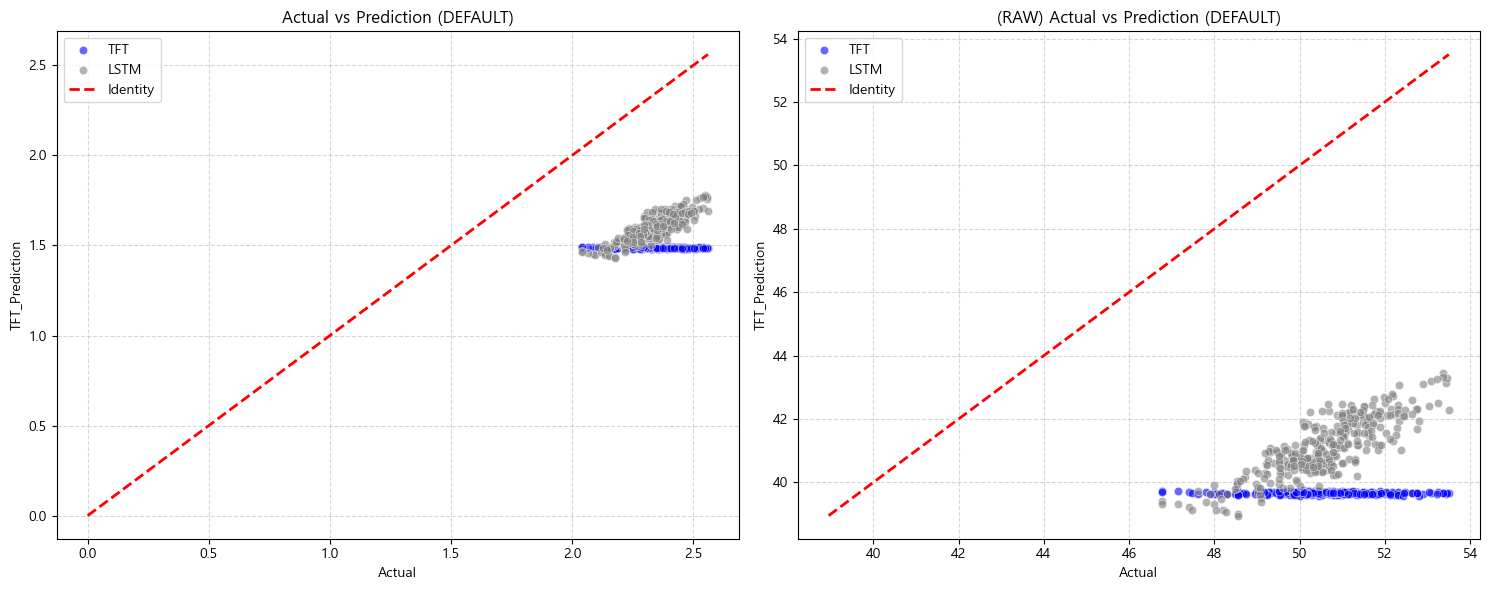

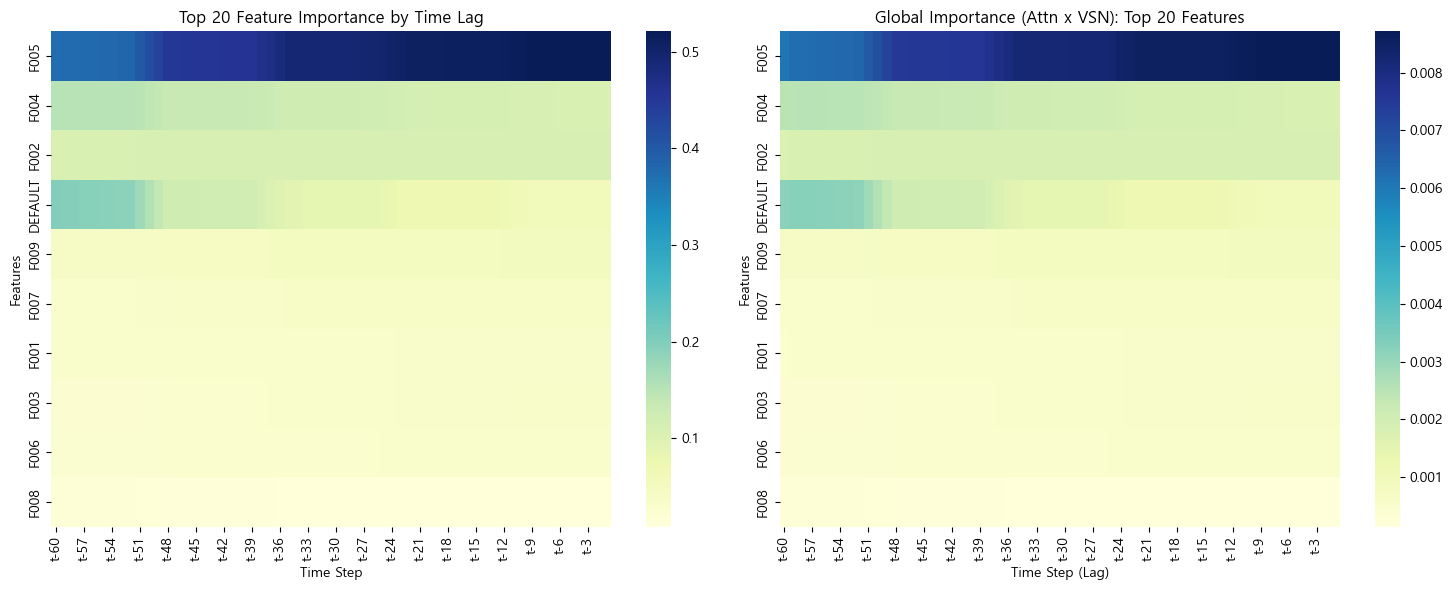

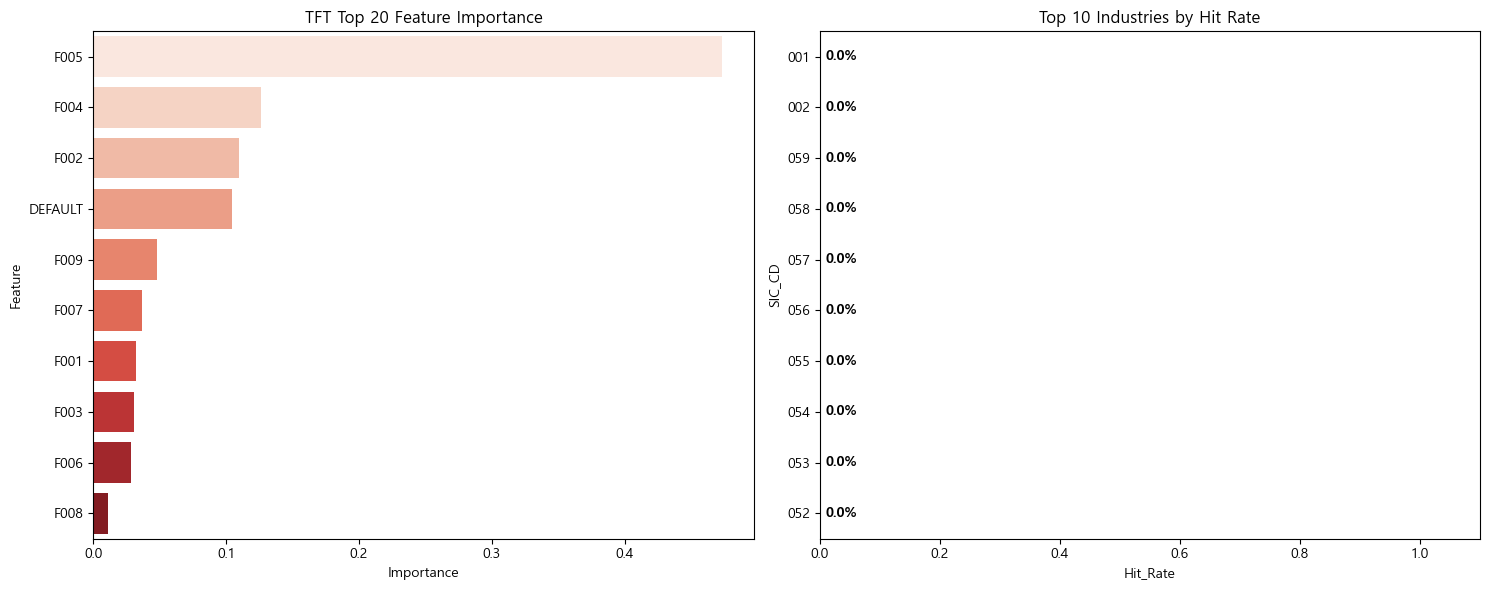

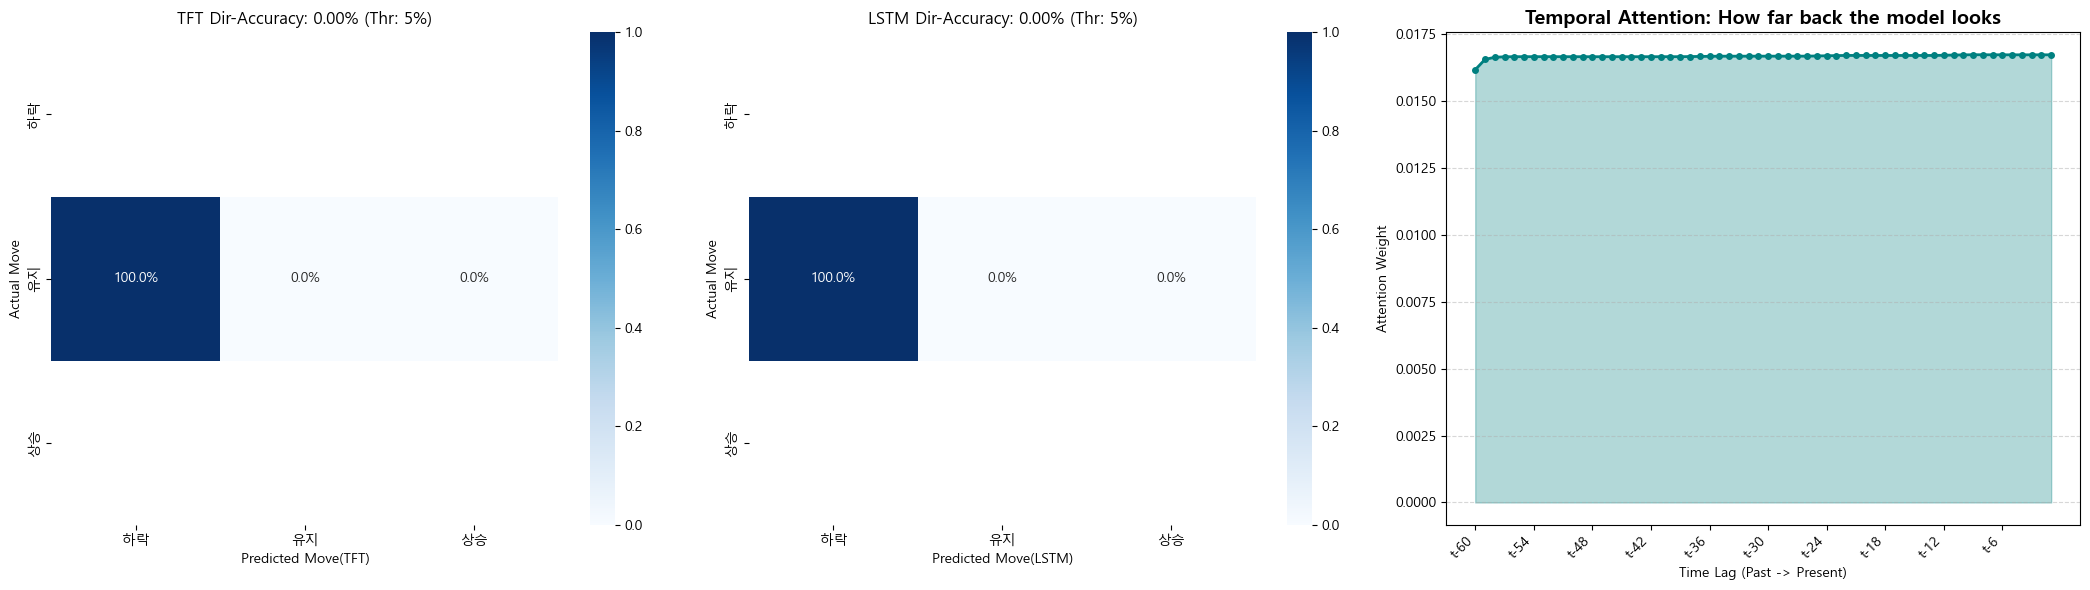

In [5]:
outdir = "./output/" + datetime.now().strftime('%y%m%d%H%M%S')+"/"
os.mkdir(outdir)
var_list = [x for x in df.columns if x.startswith('F')]+['DEFAULT']

config = {'d_model':64,
    'hidden_dim': 4,#128
    'lstm_hidden': 4,#128
    'n_heads': 4,
    'dropout': 0.2,

    'past_vars': len(var_list),
    'known_vars':  1,   # 예: time index, month, quarter 등
    'static_vars':  1,
    'output_mode': "regression"  # "regression" | "binary" | "multiclass"
}

fit_and_out(df,'DEFAULT', outdir,config,var_list,epochs=3,patience=2,threshold=0.05)

=====target : 10 DEFAULT=====
train: 201101~201812 자료 추출 중
validation set : 201501~201912 자료 추출 중
test set : 201701~202112 자료 추출 중
TFT Directional Accuracy: 0.0000
LSTM Directional Accuracy: 0.0000
0.9306143 0.9255496 0.54510003 0.53987825
########## 중요도(1) 일반공변량 ##########
########## 중요도(2) 시계열에 따른 일반공변량 ##########
########## 중요도(3) 전체 중에서 중요 공변량 ##########
########## 중요도(4) 산업별 성능 집계 ##########
########## 산업별(grp_cd) 성능 분석 중 ##########
============================== Visualization中 ==============================
==========시각화(1) Scatter Plot==========
==========시각화(2) Scatter Plot(RAW)==========
==========시각화(3) 시계열 변수중요도==========
==========시각화(4) 글로벌 중요도==========
==========시각화(5) 평균 변수중요도==========
==========시각화(6) 산업별 중요도(10개 sample)==========


c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_inference.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax5, palette='Reds')
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_inference.py:276: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_ind, x='Hit_Rate', y=grp_cd, ax=ax6, palette='Greens_r')


==========시각화(7) 변동 방향성 혼동행렬(TFT)==========
==========시각화(8) 변동 방향성 혼동행렬(LSTM)==========
==========시각화(9) Temporal Attention Score==========


c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_inference.py:293: RuntimeWarning: invalid value encountered in divide
  sns.heatmap(cm_tft / cm_tft.sum(axis=1)[:, None], annot=True, fmt=".1%", cmap='Blues', ax=ax7,
c:\Users\rbs\Dropbox\003. Work_NICE\001_우리은행AX\산업재무\regression\run_inference.py:301: RuntimeWarning: invalid value encountered in divide
  sns.heatmap(cm_lstm / cm_lstm.sum(axis=1)[:, None], annot=True, fmt=".1%", cmap='Blues', ax=ax8,


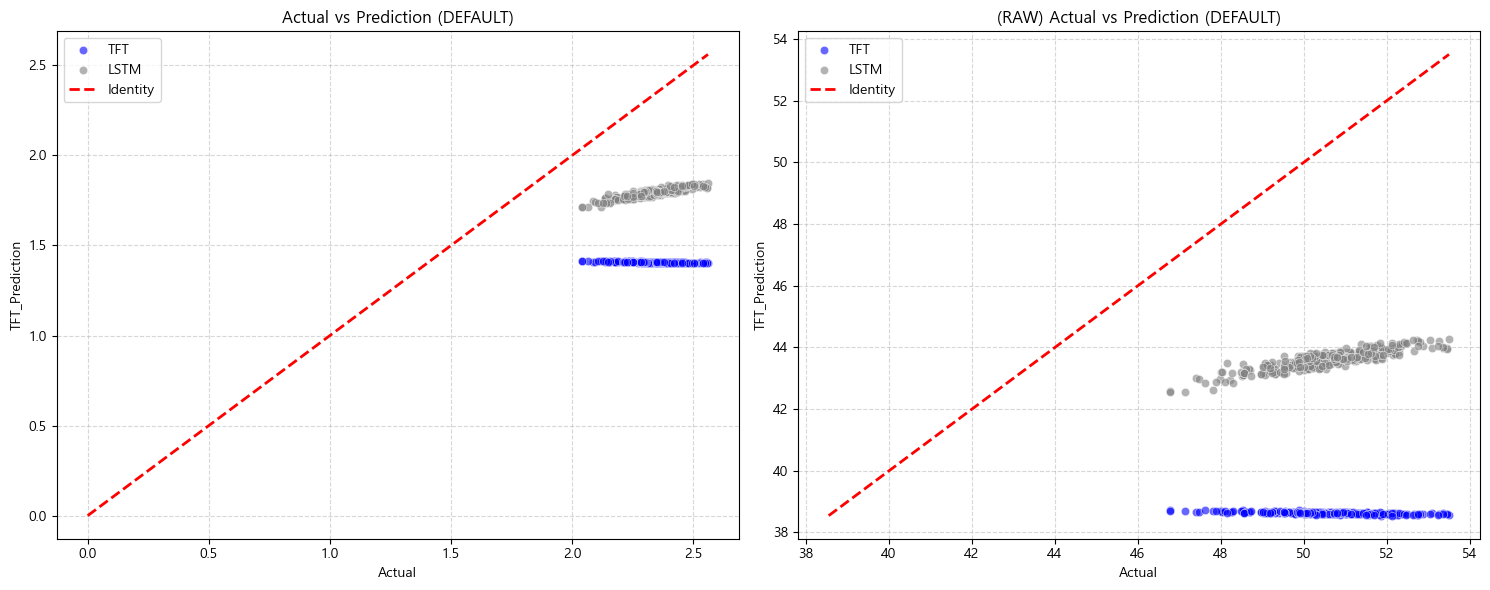

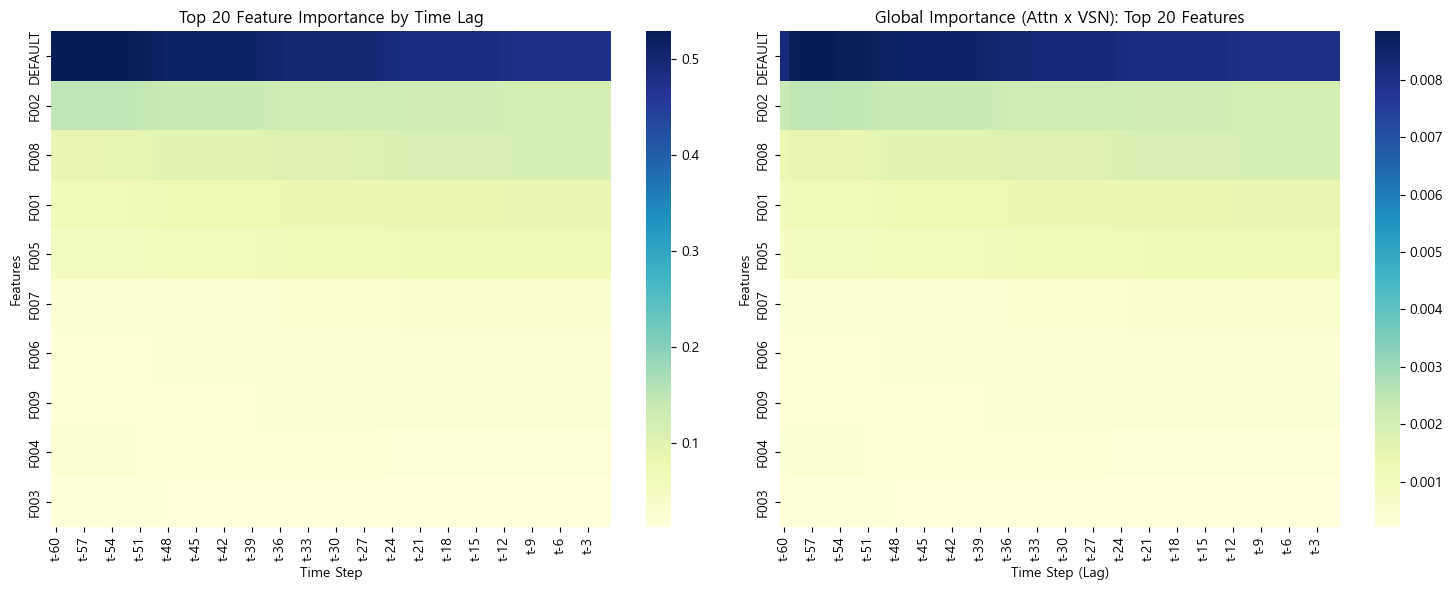

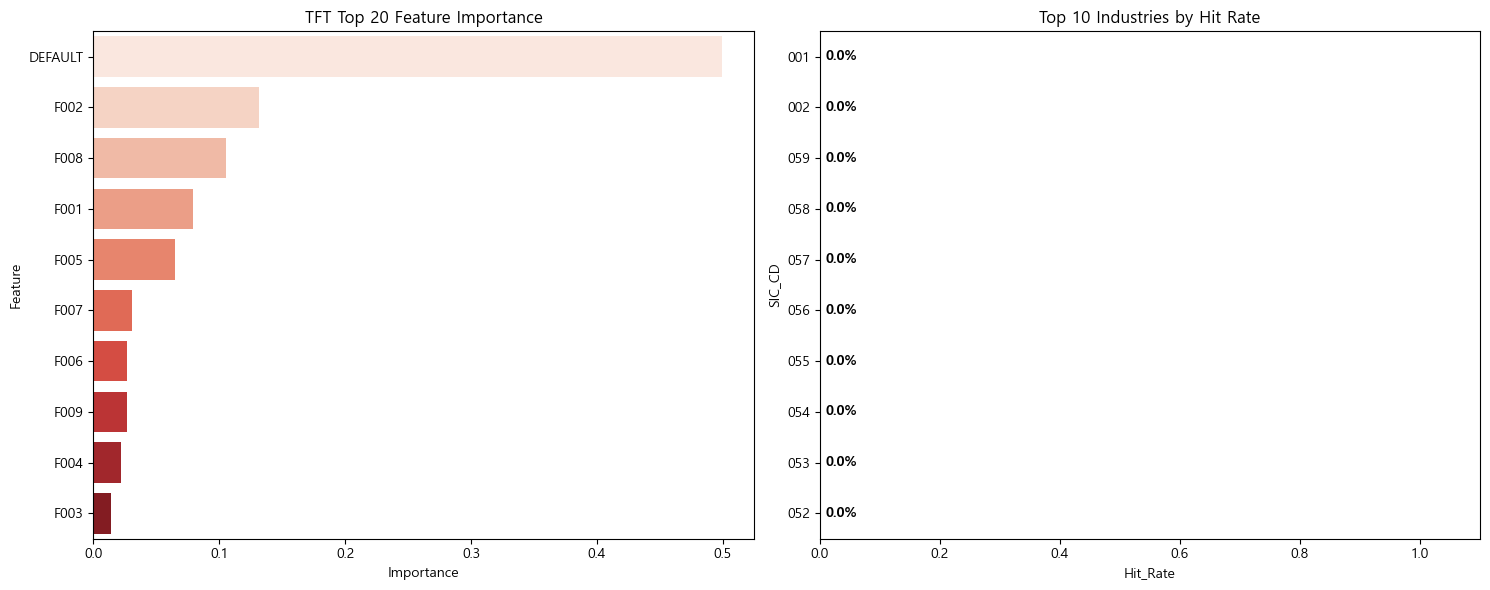

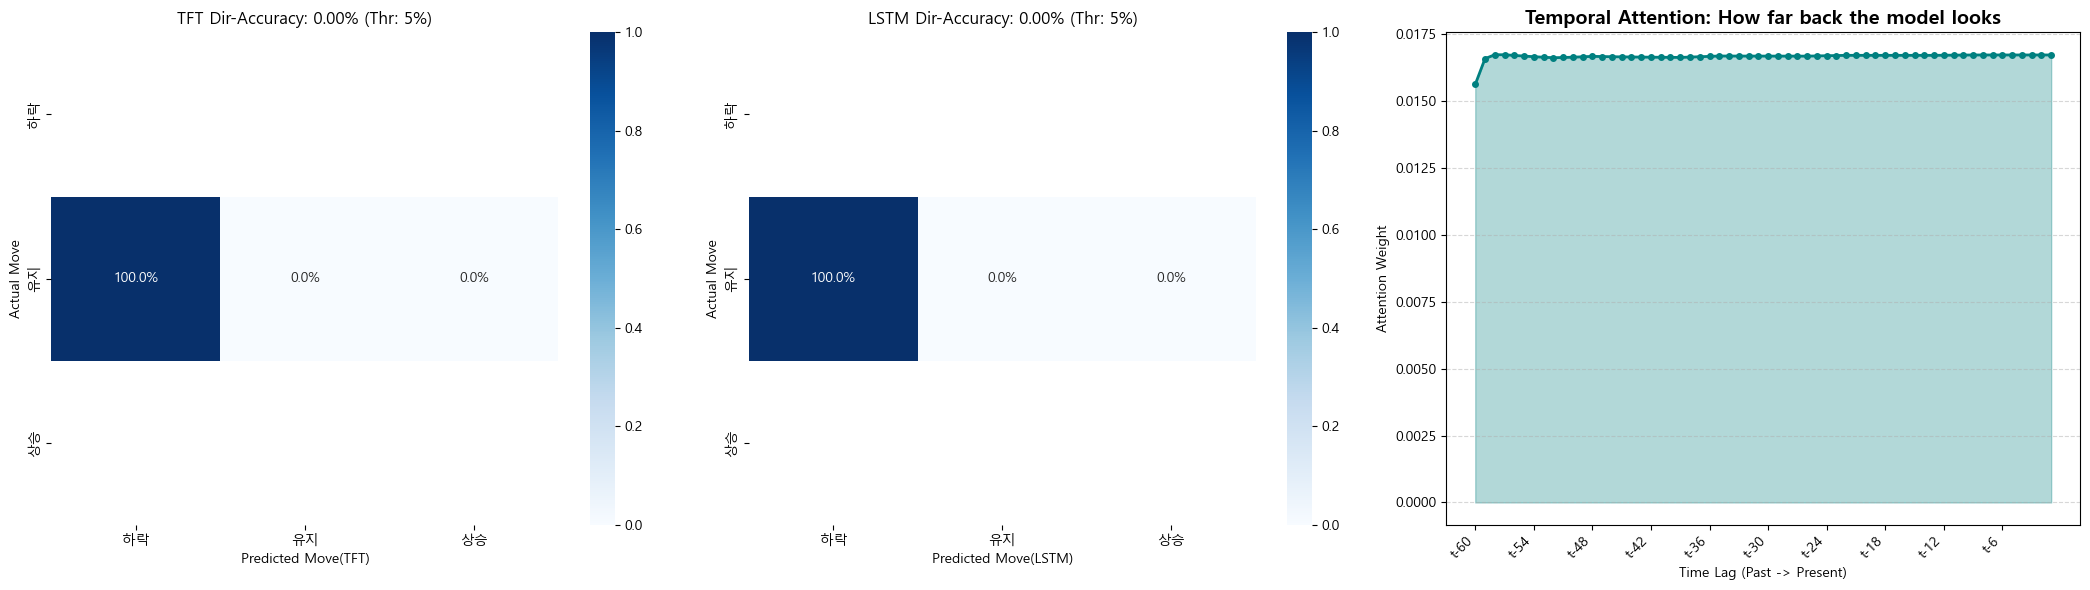

In [4]:
run_inference(df, 
                  'DEFAULT', 
                  outdir+ '/' + 'DEFAULT_tft_test_260404.pt', 
                  outdir+ '/' + 'DEFAULT_lstm_test_260404.pt', 
                  outdir, 
                  var_list)